# https://tinyurl.com/54c5tajh

# Introduction to Artificial Neural Networks with PyTorch

## 1. Setup

We need to import PyTorch, its neural network modules and matplotlib.pyplot for visualisation

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

## 2. Tensors

In this context Tensors are multidimensional arrays that can be processed on a GPU

For this reason they are suitable for storing deep learning data and model weights

In [ ]:
# creating a tensor from a list
data = [
    [1, 2],
    [3, 4]
]
x_data = torch.tensor(data)

# creating a random tensor
random_tensor = torch.rand(size=(2, 3))

# printing out information about tensors
print(f"Tensor from a list:\n\t {x_data}")
print(f"Random tensor:\n\t {random_tensor}")
print(f"Tensor shape:\n\t {x_data.size()}")
print(f"Tensor datatype:\n\t {x_data.dtype}")
print(f"Tensor device:\n\t {x_data.device}");

Tensor from a list:
	 tensor([[1, 2],
        [3, 4]])
Random tensor:
	 tensor([[0.3578, 0.7833, 0.8893],
        [0.7180, 0.0031, 0.2045]])
Tensor shape:
	 torch.Size([2, 2])
Tensor datatype:
	 torch.int64
Tensor device:
	 cpu


## 3. The Linear Layer
A linear layer (also known as a fully connected or dense layer) applies a linear transformation to the incoming data: $y = xA^T + b$.

In [ ]:
# Defining a simple linear layer with 3 input features and 2 output features
linear_layer = nn.Linear(in_features = 3, out_features = 2)

# Pass our random tensor through the linear layer
linear_layer_output = linear_layer(random_tensor)

# Check output shape
print(f"Output:\n\t {linear_layer_output.size()}")

Output:
	 torch.Size([2, 2])


## 4. Activation Functions

Without non-linear activation functions, a neural network is just a compostion of linear transformations, which is again a linear transformation. We use functions like ReLU (Rectified Linear Unit) to allow the model to learn complex, non-linear relationships.

In [ ]:
relu = nn.ReLU()
sample_input = torch.tensor([-1.0, 0.0, 1.0])
sample_output = relu(sample_input)

print(f"Sample output:\n\t {sample_output}")

Sample output:
	 tensor([0., 0., 1.])


## 5. Building a simple neural network

In [ ]:
# simple regression net
class RegressionNet(nn.Module):
  def __init__(self, input_features, hidden_features):
    super().__init__()

    self.layer1 = nn.Linear(in_features = input_features, out_features = hidden_features);
    self.relu = nn.ReLU()
    self.layer2 = nn.Linear(in_features = hidden_features, out_features = 1)

  def forward(self, x):
    x = self.layer1(x)
    x = self.relu(x)
    return self.layer2(x)

In [ ]:
test_model = RegressionNet(3, 2)
print(test_model)

RegressionNet(
  (layer1): Linear(in_features=3, out_features=2, bias=True)
  (relu): ReLU()
  (layer2): Linear(in_features=2, out_features=1, bias=True)
)


## 6 Training and evaluation

### 6.1 Data Loading and Preprocessing

In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

In [ ]:
# load data
housing = fetch_california_housing()
X, y = housing.data, housing.target
print(X.shape)
print(y.shape)

(20640, 8)
(20640,)


In [ ]:
# Train Test Val split
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2)

X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.25)


In [ ]:
# 3. Convert to PyTorch Tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [ ]:
# 4. Scale the features using PyTorch (based on training statistics only)
mean = X_train_t.mean(dim=0)
std = X_train_t.std(dim=0)

X_train_t = (X_train_t - mean) / std
X_val_t = (X_val_t - mean) / std
X_test_t = (X_test_t - mean) / std

## 6.2 training loop

In [ ]:
# Initialize Model, Loss, and Optimizer
model = RegressionNet(input_features=X_train_t.size(1), hidden_features=64)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [ ]:
# actual training loop
train_losses = []
val_losses = []

print(f"Training size: {len(X_train)}, Validation size: {len(X_val)}, Test size: {len(X_test)}")
print("Starting training...")
for epoch in range(200):
    model.train()
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    # Use validation set for tracking
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_t)
        val_loss = criterion(val_outputs, y_val_t)
        val_losses.append(val_loss.item())

    if (epoch + 1) % 40 == 0:
        print(f'Epoch [{epoch+1}/200], Train MSE: {loss.item():.4f}, Val MSE: {val_loss.item():.4f}')

Training size: 12384, Validation size: 4128, Test size: 4128
Starting training...
Epoch [40/200], Train MSE: 0.6623, Val MSE: 0.5889
Epoch [80/200], Train MSE: 0.4633, Val MSE: 0.4181
Epoch [120/200], Train MSE: 0.4175, Val MSE: 0.3787
Epoch [160/200], Train MSE: 0.3960, Val MSE: 0.3613
Epoch [200/200], Train MSE: 0.3792, Val MSE: 0.3484


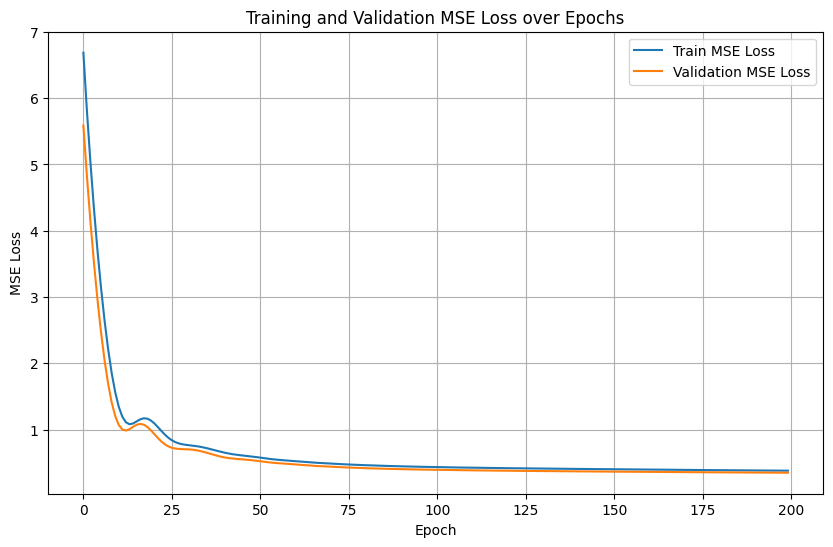

In [ ]:
# Plot the training and validation loss curves
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train MSE Loss')
plt.plot(val_losses, label='Validation MSE Loss')
plt.title('Training and Validation MSE Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

### 6.3 Evaluation



After training, we should check how the model performs on unseen data. In this phase, we again use `model.eval()` and `torch.no_grad()` to ensure we aren't tracking gradients, which saves memory and computation.

In [ ]:
# Final performance measurement on the untouched test set
model.eval()
with torch.no_grad():
    predictions = model(X_test_t)
    test_loss = criterion(predictions, y_test_t)

print(f"Final Unseen Test MSE: {test_loss.item():.4f}")

Final Unseen Test MSE: 0.4039


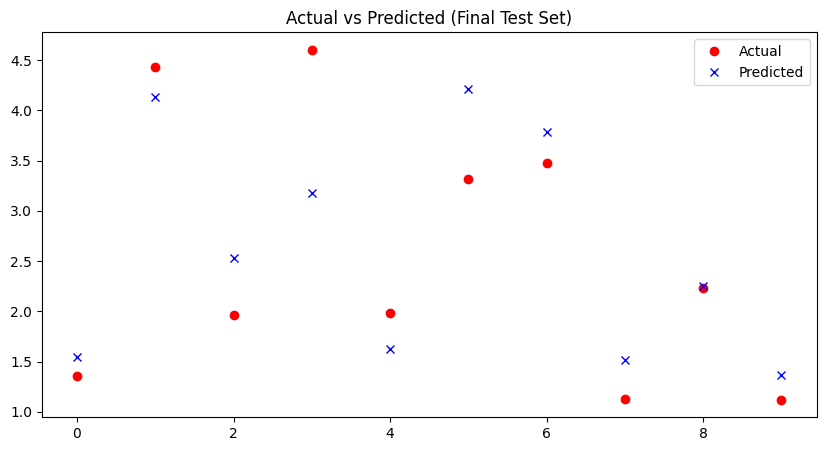

In [ ]:
# Visualize first 10 predictions vs actual values from the test set
plt.figure(figsize=(10, 5))
plt.plot(y_test[:10], 'ro', label='Actual')
plt.plot(predictions[:10].numpy(), 'bx', label='Predicted')
plt.title('Actual vs Predicted (Final Test Set)')
plt.legend()
plt.show()